In [1]:
%pip install kagglehub[pandas-datasets]


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


<h1>Treinando o modelo de clusterização GMM </h1>

In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np

file_path = "iris.csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "himanshunakrani/iris-dataset",
  file_path
)

print("First 5 records:", df.head())

c:\Users\maria\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\maria\AppData\Local\Temp\ipykernel_13344\2685341338.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


First 5 records:    sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [3]:


def aplicar_gmm(dados, n_clusters):
    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    gmm.fit(dados)
    labels = gmm.predict(dados)
    return labels, gmm.means_


def calcular_inertia(dados, n_clusters):
    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    gmm.fit(dados)
    return gmm.lower_bound_


def plotar_clusters(dados, labels, centroids):
    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(dados.iloc[:, 0], dados.iloc[:, 1], c=labels, cmap='viridis', alpha=0.6)
    plt.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=200, label='Centroids')
    plt.xlabel(dados.columns[0])
    plt.ylabel(dados.columns[1])
    plt.title('GMM Clustering')
    plt.legend()
    plt.show()

def treinar_modelo_gmm(dados, n_clusters):
    gmm = GaussianMixture(n_components=n_clusters, random_state=42)
    gmm.fit(dados)
    return gmm

def obter_cluster(modelo, novos_dados):
    return modelo.predict(novos_dados)

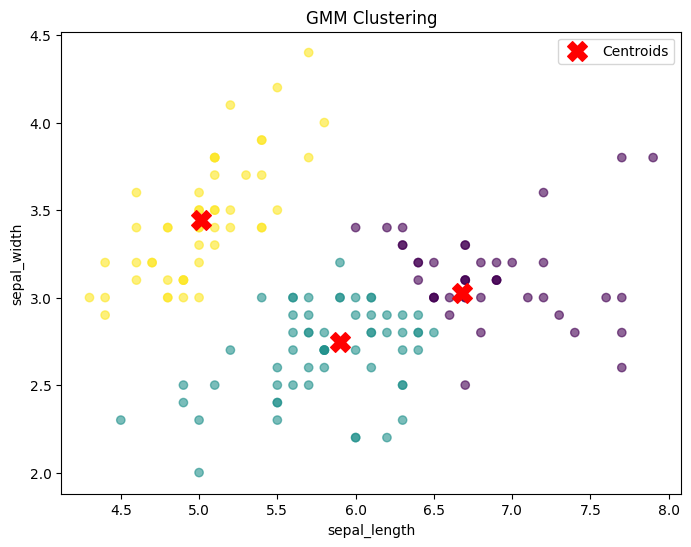

In [4]:
aplicar_gmm(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']], 3)
calcular_inertia(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']], 3)
plotar_clusters(df[['sepal_length', 'sepal_width']],
                *aplicar_gmm(df[['sepal_length', 'sepal_width']], 3)[0:2])

In [7]:
def silhouette_metrica(dados, labels):
    from sklearn.metrics import silhouette_score
    score = silhouette_score(dados, labels)
    print(f'Silhouette Score: {score:.4f}')
    return score

silhouette_metrica(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']],
    aplicar_gmm(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']], 3)[0])

Silhouette Score: 0.5009


0.5009470350205055

In [8]:
def calcular_metricas_gmm(modelo_gmm, dados):
    """
    Calcula e retorna as principais métricas de avaliação para o modelo GMM.
    
    Parâmetros:
    - modelo_gmm: Modelo GaussianMixture já treinado (fit).
    - dados: Os dados utilizados no treinamento (necessários para as métricas).
    
    Retorna:
    - Um dicionário com os valores de AIC e BIC.
    """
    # Calculando as métricas através dos métodos nativos do scikit-learn
    aic = modelo_gmm.aic(dados)
    bic = modelo_gmm.bic(dados)
    
    print("Métricas de Avaliação GMM:")
    print(f"AIC (Akaike Information Criterion): {aic:.4f}")
    print(f"BIC (Bayesian Information Criterion): {bic:.4f}")
    
    return {'AIC': aic, 'BIC': bic}
modelo_gmm = treinar_modelo_gmm(df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']], 3)
calcular_metricas_gmm(modelo_gmm, df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']])

Métricas de Avaliação GMM:
AIC (Akaike Information Criterion): 450.0163
BIC (Bayesian Information Criterion): 582.4842


{'AIC': np.float64(450.0162881281659), 'BIC': np.float64(582.4842410684012)}

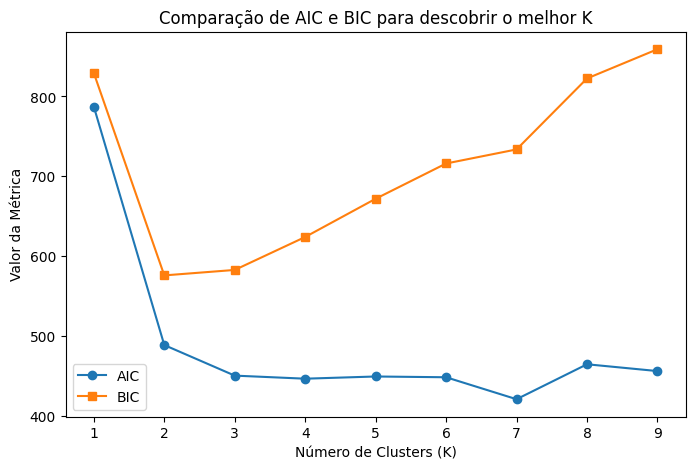

In [ ]:



colunas = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
dados = df[colunas]

valores_k = range(1, 10)
aic_valores = []
bic_valores = []

for k in valores_k:
    gmm = GaussianMixture(n_components=k, random_state=42)
    gmm.fit(dados)
    aic_valores.append(gmm.aic(dados))
    bic_valores.append(gmm.bic(dados))

# Plotando os resultados
plt.figure(figsize=(8, 5))
plt.plot(valores_k, aic_valores, label='AIC', marker='o')
plt.plot(valores_k, bic_valores, label='BIC', marker='s')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Valor da Métrica')
plt.title('Comparação de AIC e BIC para descobrir o melhor K')
plt.legend()
plt.xticks(valores_k)
plt.show()
